In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
train = pd.read_csv('../data/forecast_train.csv', parse_dates=['timestamp'])
test  = pd.read_csv('../data/forecast_test.csv',  parse_dates=['timestamp'])

In [9]:
# Quick overview
train.head()

,timestamp,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,forecast_zephyr,forecast_boreas,actual_mw
0,2024-08-01 00:00:00,-61.862703,142.349008,12.747417,3.174739,40.357354,56.600269,28.011959,-37.428053,99.865707,...,-57.206920,-81.256057,66.783275,9.599005,-100.743813,-7.704137,-40.739528,574.081956,494.539968,506.497862
1,2024-08-01 01:00:00,-45.888733,83.852442,10.359977,21.212798,29.339619,46.718673,-5.521119,-7.187384,133.386806,...,9.524266,-48.100021,10.176897,5.465612,-7.494199,1.125393,-38.953495,580.098464,491.772875,517.393125
2,2024-08-01 02:00:00,-48.304941,99.982971,12.229381,8.194864,0.791064,43.001056,-11.083204,-19.555910,106.779528,...,-42.142713,-52.843723,34.695413,5.826253,-65.500466,-11.379266,-49.815309,609.253697,525.681890,533.984735
3,2024-08-01 03:00:00,-55.389187,107.742835,12.427509,-10.460110,49.167427,49.403362,-3.061455,-6.009953,95.792196,...,-37.291848,-79.344767,55.661325,17.320486,-41.880409,-14.046735,-61.185967,560.792059,626.637097,586.130567
4,2024-08-01 04:00:00,-67.154621,114.802077,12.301098,6.022369,41.170824,26.046500,3.300123,-11.210541,86.950222,...,-2.629173,-60.527968,52.224728,4.943545,-95.965882,-24.719644,-35.203174,658.720954,570.782486,586.906892


In [10]:
train.info()
print()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7027 entries, 0 to 7026
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        7027 non-null   datetime64[ns]
 1   feature_0        7027 non-null   float64       
 2   feature_1        7027 non-null   float64       
 3   feature_2        7027 non-null   float64       
 4   feature_3        7027 non-null   float64       
 5   feature_4        7027 non-null   float64       
 6   feature_5        7027 non-null   float64       
 7   feature_6        7027 non-null   float64       
 8   feature_7        7027 non-null   float64       
 9   feature_8        7027 non-null   float64       
 10  feature_9        7027 non-null   float64       
 11  feature_10       7027 non-null   float64       
 12  feature_11       7027 non-null   float64       
 13  feature_12       7027 non-null   float64       
 14  feature_13       7027 non-null   float64

,timestamp,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,forecast_zephyr,forecast_boreas,actual_mw
count,7027,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,...,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000
mean,2024-12-25 08:59:59.999999744,-52.320881,72.024285,11.151600,13.388959,36.951315,18.853537,8.590485,-11.043389,100.010104,...,-36.669332,-61.476982,8.369763,6.482728,-37.063717,-17.020763,-42.429133,478.082832,455.380092,449.776439
min,2024-08-01 00:00:00,-119.686242,-53.099108,5.000000,-40.002746,-37.826370,-109.703974,-49.699175,-51.265037,38.200114,...,-165.457245,-128.304131,-119.313267,-33.329156,-141.246410,-56.062992,-100.319238,249.300291,204.905553,274.355537
25%,2024-10-13 04:30:00,-65.401540,47.158822,9.650736,3.124856,21.140368,-4.952744,-1.629661,-18.468865,88.737425,...,-57.314558,-74.676480,-19.720635,-0.727373,-58.884342,-24.278647,-53.549334,398.994592,388.260139,392.235305
50%,2024-12-25 09:00:00,-51.716056,77.200501,11.142278,13.308002,35.905448,21.867393,8.675148,-11.110145,100.315274,...,-32.440754,-61.279706,12.311891,6.471033,-37.240409,-17.006136,-42.103895,474.614644,450.796938,449.503145
75%,2025-03-08 13:30:00,-38.895427,99.224944,12.623876,23.653299,52.020864,45.000209,18.774729,-3.526516,111.079517,...,-13.069588,-47.589115,38.303438,13.692382,-15.338009,-9.710490,-31.101120,548.749683,520.592599,506.759396
max,2025-05-20 18:00:00,1.989543,185.559364,17.000000,67.667861,138.308721,129.153388,64.734642,28.389856,160.055205,...,70.034186,-1.132036,133.678334,52.272052,74.777834,21.487697,12.741918,806.247368,730.092019,620.988036
std,NaN,18.696238,36.766925,2.052469,15.046311,22.959638,36.465233,15.120557,11.051975,16.502345,...,32.796859,19.399779,41.340871,10.629377,31.422846,10.796662,16.269220,98.670279,89.126245,74.859885


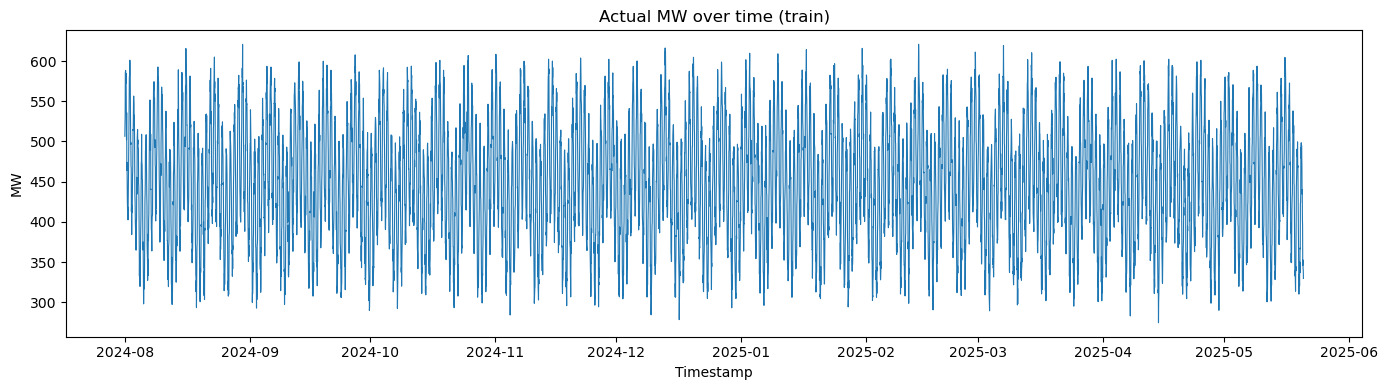

In [11]:
# Plot actual power output over time
plt.figure(figsize=(14, 4))
plt.plot(train['timestamp'], train['actual_mw'], linewidth=0.8)
plt.title('Actual MW over time (train)')
plt.xlabel('Timestamp')
plt.ylabel('MW')
plt.tight_layout()
plt.show()

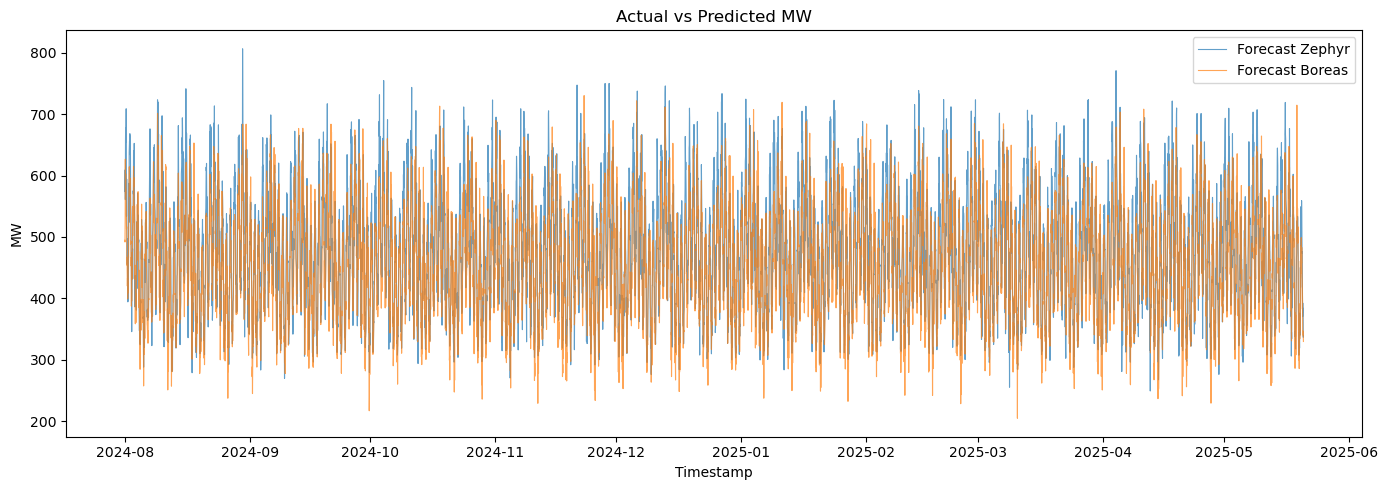

In [12]:
plt.figure(figsize=(14, 5))
# plt.plot(train['timestamp'], train['actual_mw'],      label='Actual',          linewidth=0.8)
plt.plot(train['timestamp'], train['forecast_zephyr'], label='Forecast Zephyr', linewidth=0.8, alpha=0.7)
plt.plot(train['timestamp'], train['forecast_boreas'], label='Forecast Boreas', linewidth=0.8, alpha=0.7)
plt.title('Actual vs Predicted MW')
plt.xlabel('Timestamp')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()


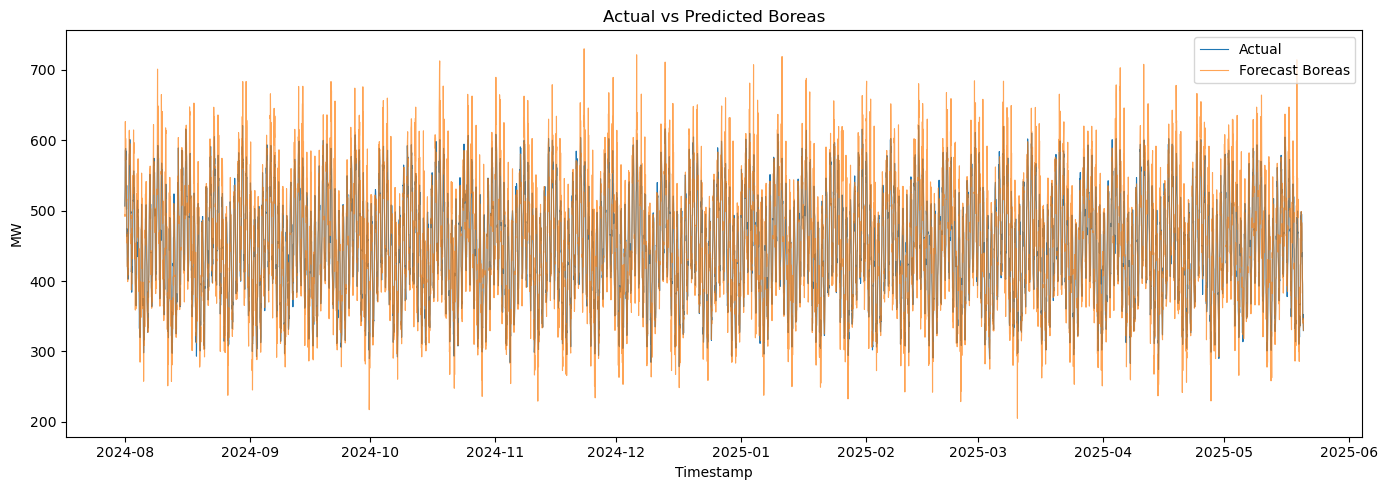

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(train['timestamp'], train['actual_mw'],      label='Actual',          linewidth=0.8)
# plt.plot(train['timestamp'], train['forecast_zephyr'], label='Forecast Zephyr', linewidth=0.8, alpha=0.7)
plt.plot(train['timestamp'], train['forecast_boreas'], label='Forecast Boreas', linewidth=0.8, alpha=0.7)
plt.title('Actual vs Predicted Boreas')
plt.xlabel('Timestamp')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()


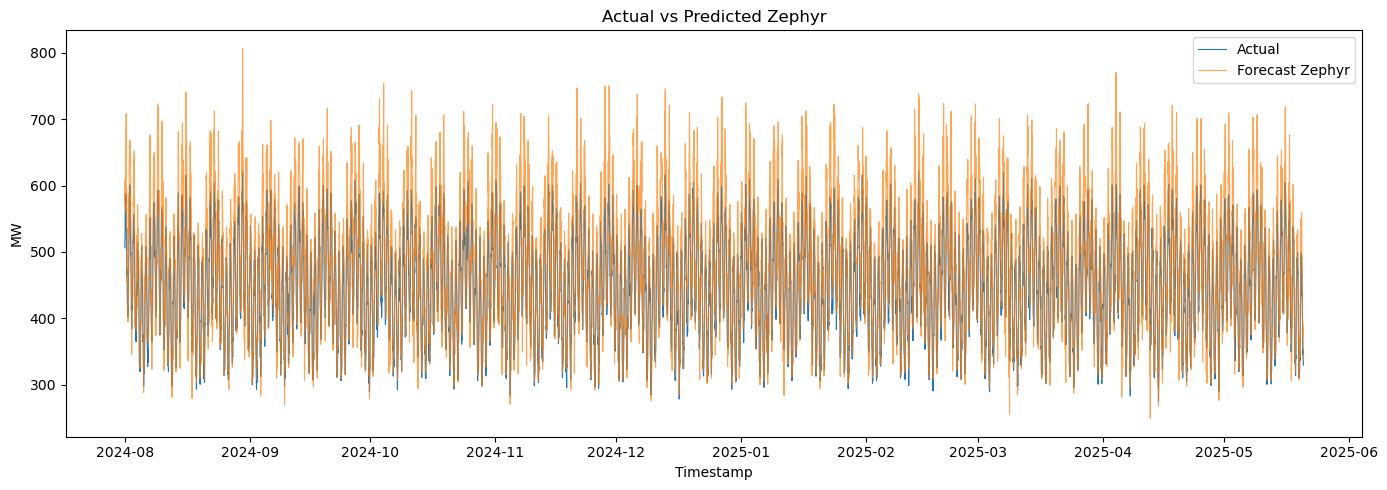

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(train['timestamp'], train['actual_mw'],      label='Actual',          linewidth=0.8)
plt.plot(train['timestamp'], train['forecast_zephyr'], label='Forecast Zephyr', linewidth=0.8, alpha=0.7)
# plt.plot(train['timestamp'], train['forecast_boreas'], label='Forecast Boreas', linewidth=0.8, alpha=0.7)
plt.title('Actual vs Predicted Zephyr')
plt.xlabel('Timestamp')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [16]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mbe  = np.mean(y_pred - y_true)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"  MAE:  {mae:.3f} MW")
    print(f"  RMSE: {rmse:.3f} MW")
    print(f"  MAPE: {mape:.2f} %")
    print(f"  MBE:  {mbe:.3f} MW")
    print(f"  R²:   {r2:.4f}")
    print()

evaluate('Zephyr', train['actual_mw'], train['forecast_zephyr'])
evaluate('Boreas', train['actual_mw'], train['forecast_boreas'])

--- Zephyr ---
  MAE:  35.234 MW
  RMSE: 46.761 MW
  MAPE: 7.45 %
  MBE:  28.306 MW
  R²:   0.6098

--- Boreas ---
  MAE:  24.044 MW
  RMSE: 33.517 MW
  MAPE: 5.40 %
  MBE:  5.604 MW
  R²:   0.7995



In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

In [18]:
def add_time_features(df):
    df = df.copy()
    df['hour']      = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek
    df['month']     = df['timestamp'].dt.month
    df['dayofyear'] = df['timestamp'].dt.dayofyear
    # Cyclical encoding so hour 23 and 0 are close
    df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    return df

train = add_time_features(train)
test  = add_time_features(test)

FEATURES = (
    [f'feature_{i}' for i in range(20)]
    + ['forecast_zephyr', 'forecast_boreas']
    + ['hour', 'dayofweek', 'month', 'dayofyear',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
)
TARGET = 'actual_mw'

X      = train[FEATURES].values
y      = train[TARGET].values
X_test = test[FEATURES].values

print(f'{len(FEATURES)} features ready.')


30 features ready.


In [31]:
base_models = {
    'xgb': xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    ),
    'lgb': lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
    ),
    'rf':  RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),
}

kf = KFold(n_splits=5, shuffle=False)
oof_preds  = np.zeros((len(X), len(base_models)))
test_preds = np.zeros((len(X_test), len(base_models)))

for i, (name, model) in enumerate(base_models.items()):
    print(f'Training {name}...')
    fold_test_preds = np.zeros((len(X_test), kf.n_splits))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        model.fit(X[tr_idx], y[tr_idx])
        oof_preds[val_idx, i]    = model.predict(X[val_idx])
        fold_test_preds[:, fold] = model.predict(X_test)

    test_preds[:, i] = fold_test_preds.mean(axis=1)
    print(f'  OOF MAE: {mean_absolute_error(y, oof_preds[:, i]):.3f} MW')

# Meta-model learns how to combine the base models
meta = Ridge()
meta.fit(oof_preds, y)
final_train_pred = meta.predict(oof_preds)
final_test_pred  = meta.predict(test_preds)
print('\nDone.')


Training xgb...
  OOF MAE: 8.425 MW
Training lgb...
  OOF MAE: 8.265 MW
Training rf...
  OOF MAE: 10.216 MW

Done.


In [33]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mbe  = np.mean(y_pred - y_true)
    r2   = r2_score(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'  MAE:  {mae:.3f} MW')
    print(f'  RMSE: {rmse:.3f} MW')
    print(f'  MAPE: {mape:.2f} %')
    print(f'  MBE:  {mbe:.3f} MW')
    print(f'  R²:   {r2:.4f}\n')

evaluate('Zephyr  (baseline)', y, train['forecast_zephyr'])
evaluate('Boreas  (baseline)', y, train['forecast_boreas'])
evaluate('XGBoost (alone)',    y, oof_preds[:, 0])
evaluate('LightGBM (alone)',   y, oof_preds[:, 1])
evaluate('Random Forest',      y, oof_preds[:, 2])
evaluate('Stack — Final',      y, final_train_pred)


--- Zephyr  (baseline) ---
  MAE:  35.234 MW
  RMSE: 46.761 MW
  MAPE: 7.45 %
  MBE:  28.306 MW
  R²:   0.6098

--- Boreas  (baseline) ---
  MAE:  24.044 MW
  RMSE: 33.517 MW
  MAPE: 5.40 %
  MBE:  5.604 MW
  R²:   0.7995

--- XGBoost (alone) ---
  MAE:  8.425 MW
  RMSE: 10.773 MW
  MAPE: 1.90 %
  MBE:  -0.062 MW
  R²:   0.9793

--- LightGBM (alone) ---
  MAE:  8.265 MW
  RMSE: 10.530 MW
  MAPE: 1.86 %
  MBE:  -0.090 MW
  R²:   0.9802

--- Random Forest ---
  MAE:  10.216 MW
  RMSE: 13.358 MW
  MAPE: 2.30 %
  MBE:  0.012 MW
  R²:   0.9682

--- Stack — Final ---
  MAE:  8.174 MW
  RMSE: 10.389 MW
  MAPE: 1.84 %
  MBE:  0.000 MW
  R²:   0.9807



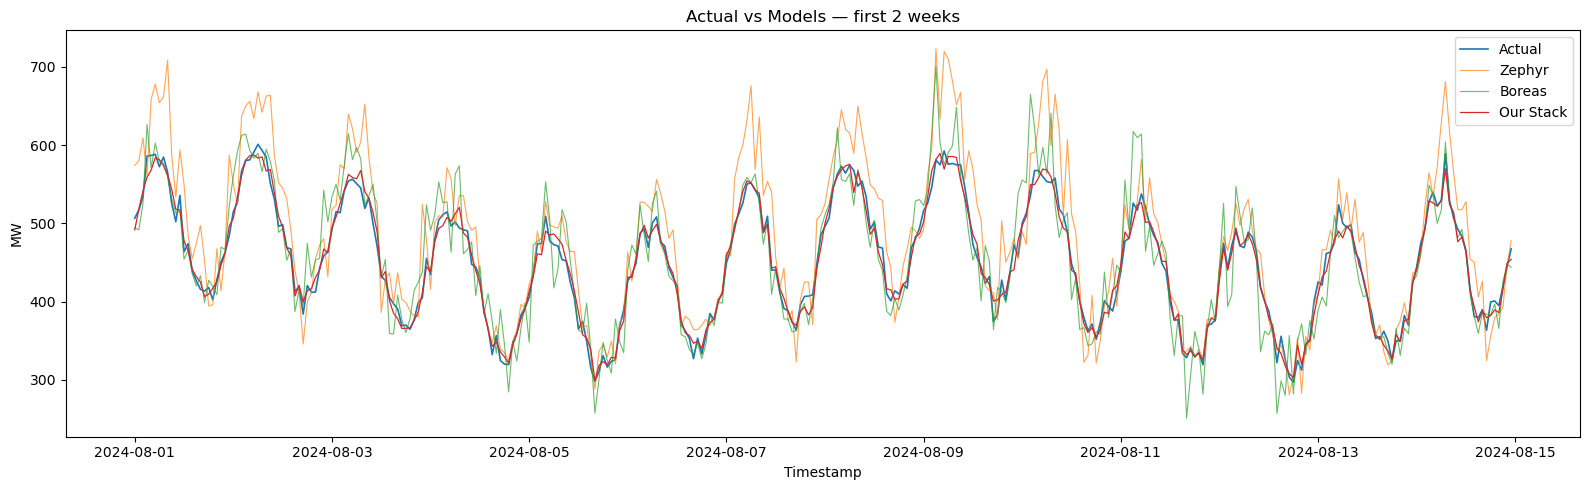

In [35]:
window = slice(0, 24 * 14)  # first 2 weeks
ts = train['timestamp'].values[window]

plt.figure(figsize=(16, 5))
plt.plot(ts, y[window],                               label='Actual',    linewidth=1.2)
plt.plot(ts, train['forecast_zephyr'].values[window], label='Zephyr',    linewidth=0.8, alpha=0.7)
plt.plot(ts, train['forecast_boreas'].values[window], label='Boreas',    linewidth=0.8, alpha=0.7)
plt.plot(ts, final_train_pred[window],                label='Our Stack', linewidth=0.9)
plt.title('Actual vs Models — first 2 weeks')
plt.xlabel('Timestamp')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
submission = test[['timestamp']].copy()
submission['predicted_mw'] = final_test_pred
submission.to_csv('../data/submission.csv', index=False)
print('Saved submission.csv')
submission.head()

Saved submission.csv


,timestamp,predicted_mw
0,2025-05-20 19:00:00,344.429002
1,2025-05-20 20:00:00,352.795242
2,2025-05-20 21:00:00,363.987864
3,2025-05-20 22:00:00,398.517609
4,2025-05-20 23:00:00,426.587542
